# Library

In [388]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# EDA

In [389]:
df = pd.read_csv('train.csv')

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [390]:
df.shape

(1460, 81)

In [391]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


Cek Missing Value

In [392]:
missing_value = df.isnull().sum()
missing_value = missing_value[missing_value > 0].sort_values(ascending=False)
print(missing_value)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


Banyak sekali missing value, jadi kita akan drop fitur yang missing value nya lebih dari 50 persen

Cek Duplikat

In [393]:
duplikat_value = df.duplicated().sum()
print(duplikat_value)

0


Cek Outlier

In [394]:
num_cols = df.select_dtypes(include=['int64', 'float64']).drop(columns=['Id'], errors='ignore').columns

outlier_summary = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 -Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    count = len(outliers)

    if count > 0:
        outlier_summary.append({
            'Fitur': col,
            'Jumlah Outlier': count,
            'Persentase': round((count/len(df)) * 100, 2)
        })

df_outlier = pd.DataFrame(outlier_summary).sort_values(by='Jumlah Outlier', ascending=False)
df_outlier

,Fitur,Jumlah Outlier,Persentase
25,EnclosedPorch,208,14.25
8,BsmtFinSF2,167,11.44
4,OverallCond,125,8.56
27,ScreenPorch,116,7.95
0,MSSubClass,103,7.05
6,MasVnrArea,96,6.58
1,LotFrontage,88,6.03
16,BsmtHalfBath,82,5.62
24,OpenPorchSF,77,5.27
2,LotArea,69,4.73


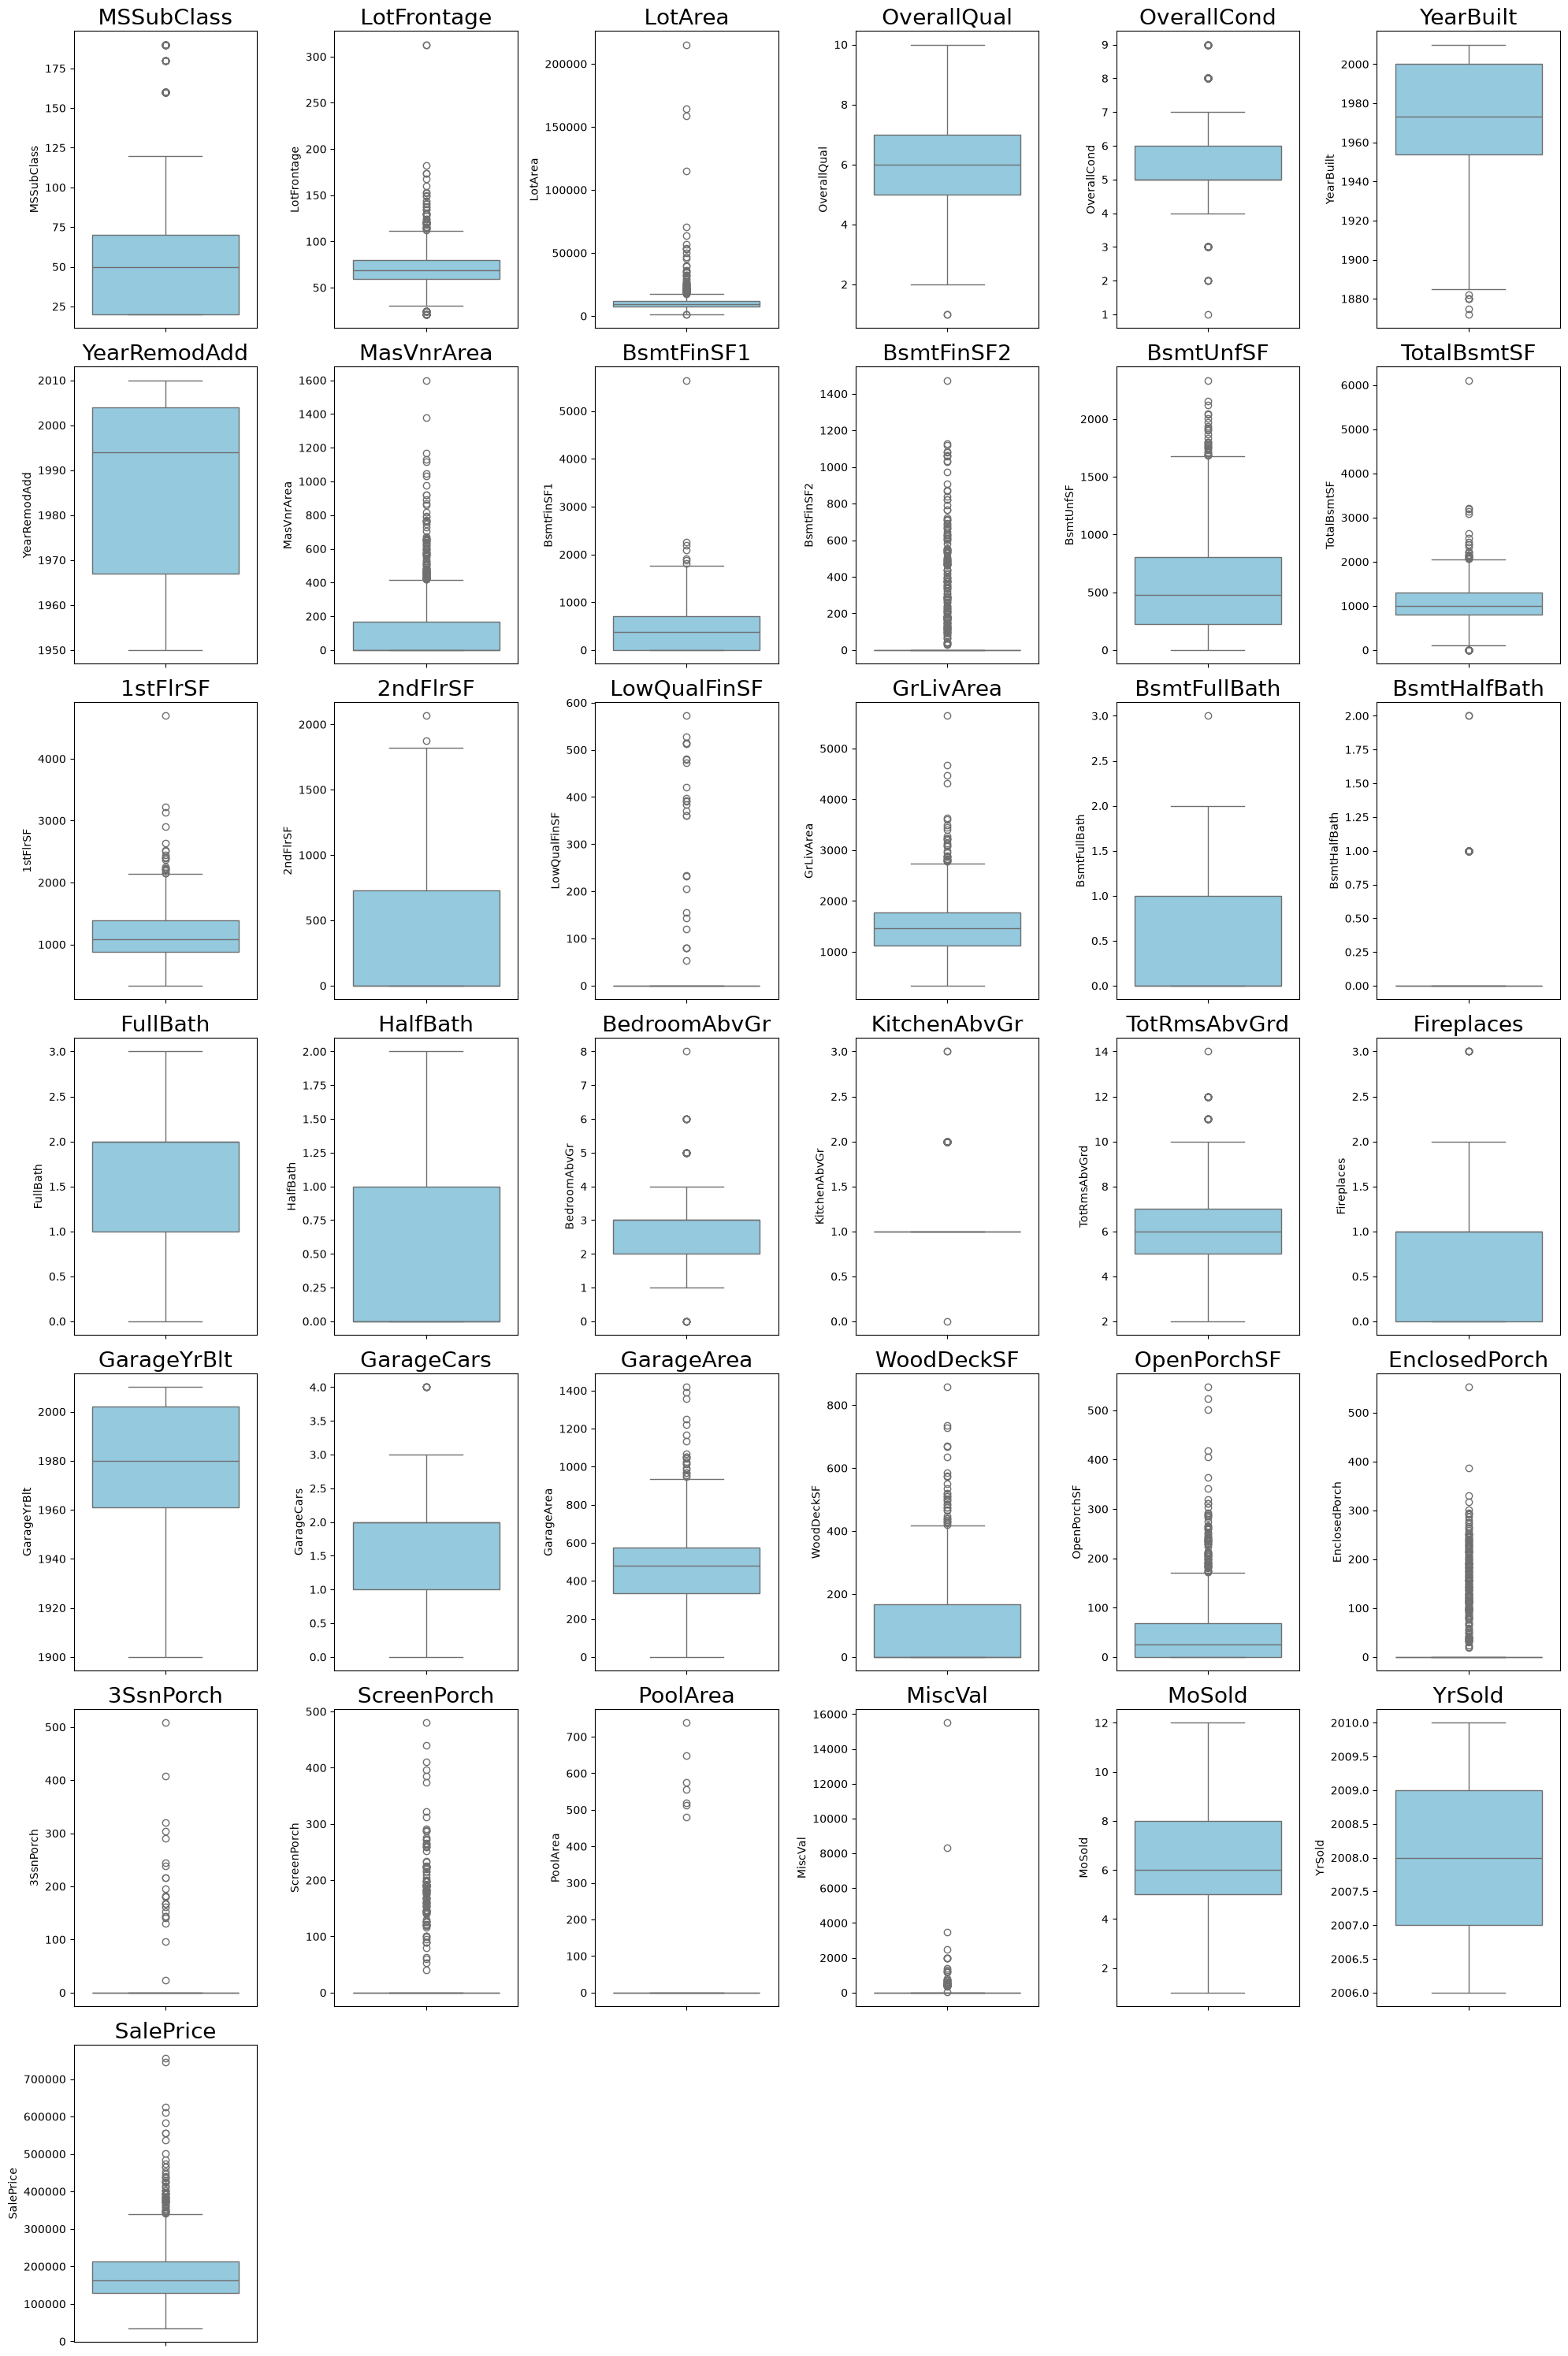

In [395]:
plt.figure(figsize=(20, 30))

for i, col in enumerate(num_cols, 1):
    plt.subplot(7, 6, i)
    sns.boxplot(
        y=df[col],
        color='skyblue'
    )
    plt.title(col, fontsize=20)
    plt.tight_layout()

plt.show()

Nanti akan ditangani di preprocessing untuk fitur fitur yang memiliki outlier

Cek Distribusi Fitur

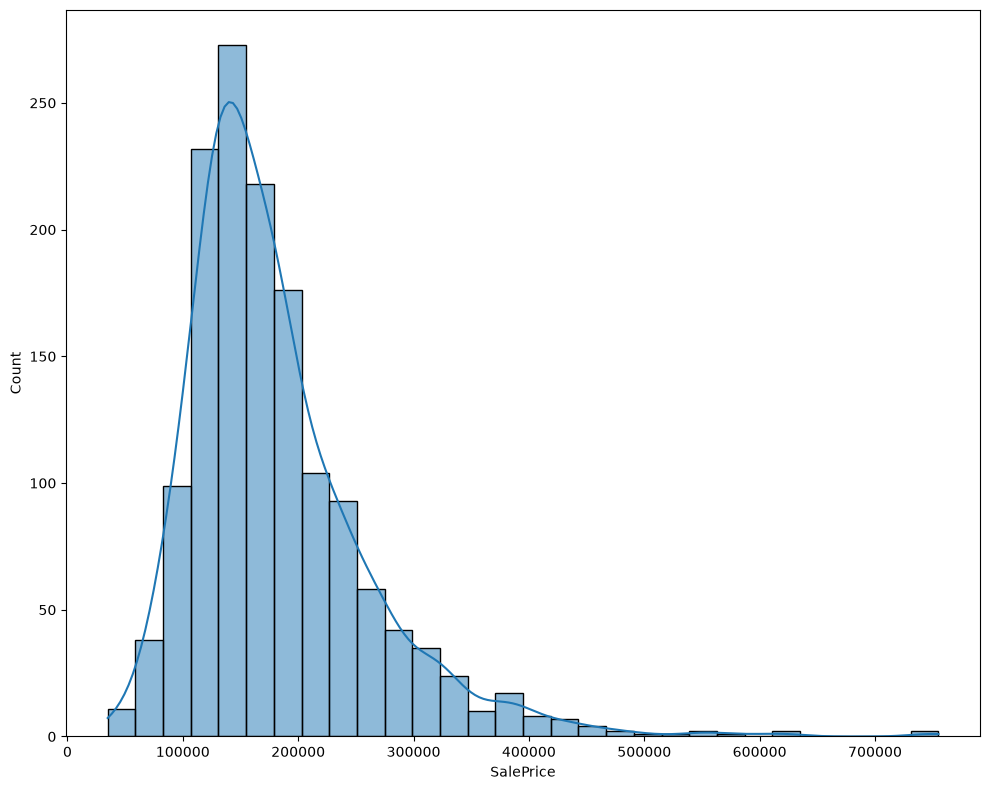

In [396]:
plt.figure(figsize=(10, 8))

sns.histplot(
    df['SalePrice'],
    bins=30,
    kde=True
)

plt.tight_layout()
plt.show()

In [397]:
corr_matrix = df.corr(numeric_only=True)
top_corr = corr_matrix['SalePrice'].sort_values(ascending=False)
print(top_corr.head(10))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


In [398]:
df[top_corr.index].nunique()


SalePrice         663
OverallQual        10
GrLivArea         861
GarageCars          5
GarageArea        441
TotalBsmtSF       721
1stFlrSF          753
FullBath            4
TotRmsAbvGrd       12
YearBuilt         112
YearRemodAdd       61
GarageYrBlt        97
MasVnrArea        327
Fireplaces          4
BsmtFinSF1        637
LotFrontage       110
WoodDeckSF        274
2ndFlrSF          417
OpenPorchSF       202
HalfBath            3
LotArea          1073
BsmtFullBath        4
BsmtUnfSF         780
BedroomAbvGr        8
ScreenPorch        76
PoolArea            8
MoSold             12
3SsnPorch          20
BsmtFinSF2        144
BsmtHalfBath        3
MiscVal            21
Id               1460
LowQualFinSF       24
YrSold              5
OverallCond         9
MSSubClass         15
EnclosedPorch     120
KitchenAbvGr        4
dtype: int64

Matriks Korelasi

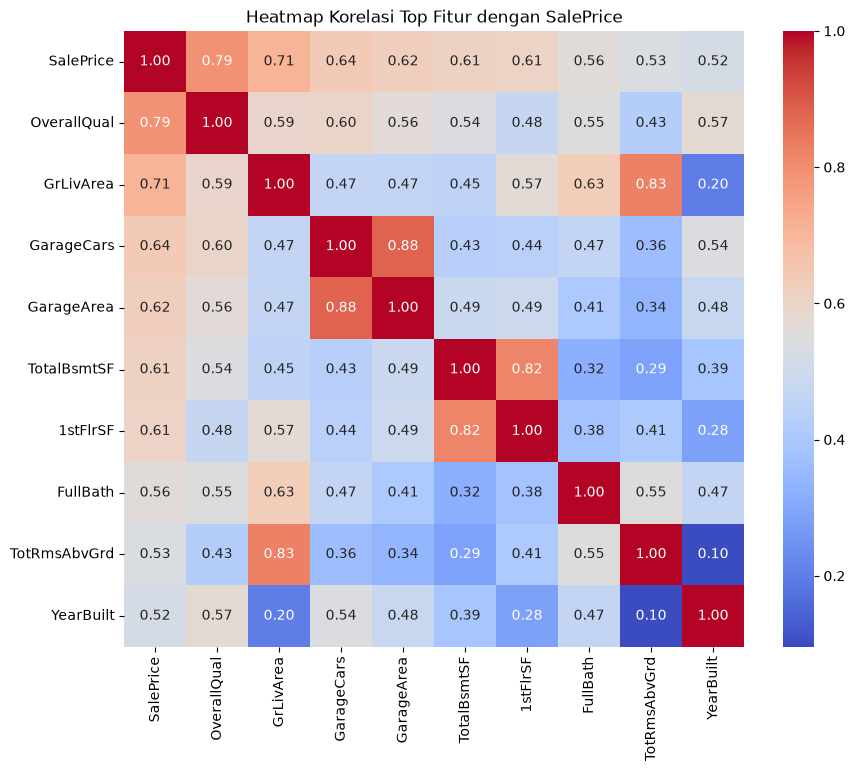

In [399]:
plt.figure(figsize=(10, 8))

top_fitur = top_corr.head(10).index

sns.heatmap(
    df[top_fitur].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Heatmap Korelasi Top Fitur dengan SalePrice")
plt.show()

Fitur paling berpengaruh terhadapa SalePrice yaitu OverallQual sama GrLivArea

Adanya Multikolinearitas:
GarageCars dan GarageArea berkorelasi sangat kuat (~0.88) karena jumlah mobil dan luas garasi pada dasarnya mengukur hal yang sama.
TotalBsmtSF dan 1stFlrSF berkorelasi ~0.82 luas lantai 1 biasanya sama dengan luas basement di bawahnya.
TotRmsAbvGrd dan GrLivArea berkorelasi ~0.83 makin luas rumah, makin banyak jumlah ruangannya.


### Scatter plot fitur numerik terhadap SalePrice

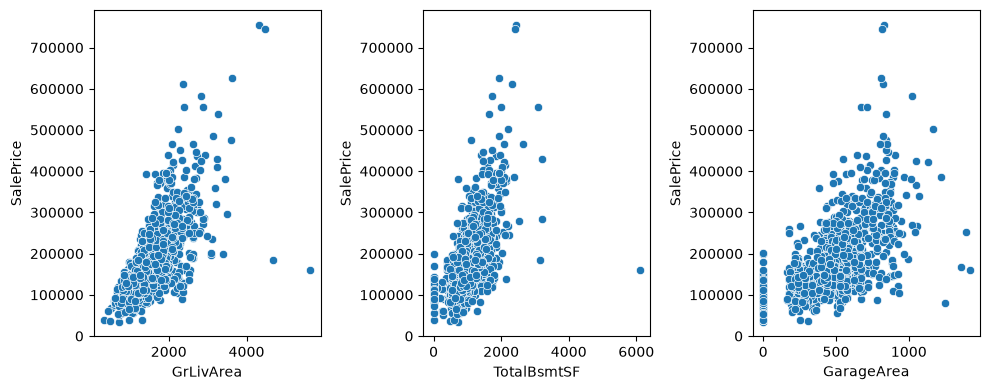

In [400]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
sns.scatterplot(
    x=df['GrLivArea'],
    y=df['SalePrice']
)

plt.subplot(1, 3, 2)
sns.scatterplot(
    x=df['TotalBsmtSF'],
    y=df['SalePrice']
)

plt.subplot(1, 3, 3)
sns.scatterplot(
    x=df['GarageArea'],
    y=df['SalePrice']
)

plt.tight_layout()
plt.show()

Bisa dilihat pada GrLivArea dengan SalePrice, ada 2 titik dimana GrLivArea nya diatas 4000, namun SalePricenya tidak tinggi, dimana hal ini termasuk anomali

### Boxplot top fitur kategorikal terhadap SalePrice

C:\Users\LAPTOPKU\AppData\Local\Temp\ipykernel_20612\2962679990.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['OverallQual'], y=df['SalePrice'], palette='Blues')
C:\Users\LAPTOPKU\AppData\Local\Temp\ipykernel_20612\2962679990.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['GarageCars'], y=df['SalePrice'], palette='Greens')


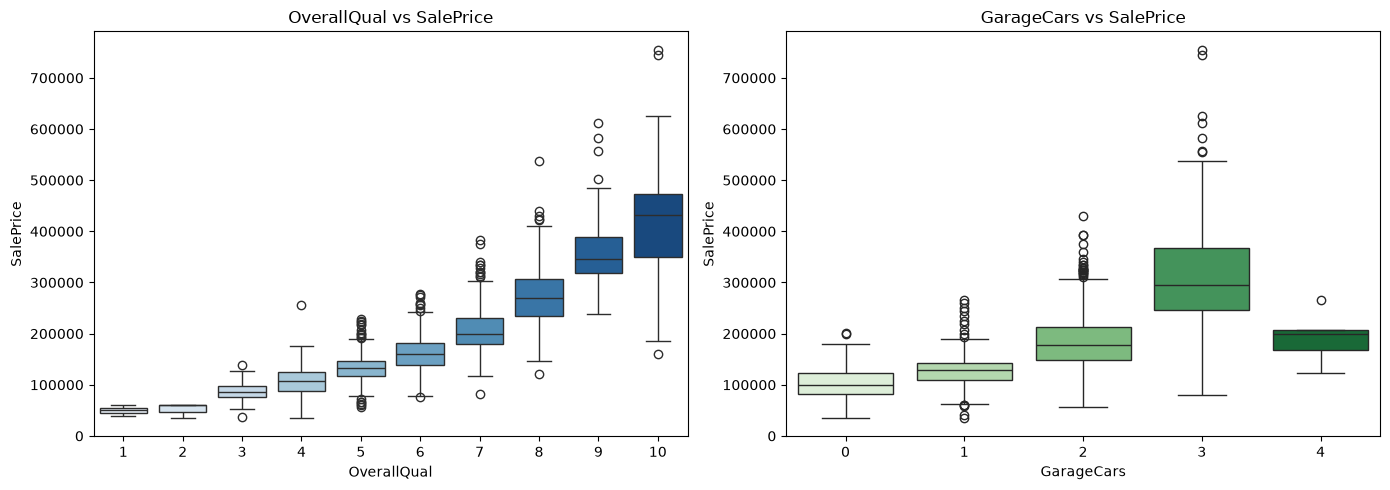

In [401]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=df['OverallQual'], y=df['SalePrice'], palette='Blues')
plt.title('OverallQual vs SalePrice')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['GarageCars'], y=df['SalePrice'], palette='Greens')
plt.title('GarageCars vs SalePrice')

plt.tight_layout()
plt.show()


# Preprocessing

In [402]:
features_drop = ['Id', 'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType']

df = df.drop(columns=features_drop)

print(df.shape)

(1460, 75)


Drop fitur yang memiliki missing_value lebih dari 50 persen dan fitur Id, karena Id adalah identifier bukan fitur prediktif

In [403]:
missing_valbaru = df.isnull().sum()
missing_valbaru = missing_valbaru[missing_valbaru> 0].sort_values(ascending=False)
print(missing_valbaru)

FireplaceQu     690
LotFrontage     259
GarageYrBlt      81
GarageFinish     81
GarageType       81
GarageQual       81
GarageCond       81
BsmtExposure     38
BsmtFinType2     38
BsmtCond         37
BsmtQual         37
BsmtFinType1     37
MasVnrArea        8
Electrical        1
dtype: int64


### Cek Fitur Kategorikal dan Numerik yang masih memiliki missing value

In [404]:
sisa_missing = df.isnull().sum()
sisa_missing = sisa_missing[sisa_missing > 0 ].index

info_missing = pd.DataFrame({
    'Tipe Data' : df[sisa_missing].dtypes,
    'Jumlah Missing' : df[sisa_missing].isnull().sum(),
    'Jumlah Unik' : df[sisa_missing].nunique()
})

info_missing

,Tipe Data,Jumlah Missing,Jumlah Unik
LotFrontage,float64,259,110
MasVnrArea,float64,8,327
BsmtQual,str,37,4
BsmtCond,str,37,4
BsmtExposure,str,38,4
BsmtFinType1,str,37,6
BsmtFinType2,str,38,6
Electrical,str,1,5
FireplaceQu,str,690,5
GarageType,str,81,6


Disini bisa dilihat fitur numerik sisa missing value nya hanya 3 jadi tinggal dilihat distribusi dari ketiga fitur tersebut untuk di handling nanti menggunakan mean atau median

Sisanya yaitu fitur kategorikal saja tinggal diisi 'None' dan karena Electrical cuma 1 missing value, bisa diisi dengan modus

### Cek distribusi fitur numerik yang masi memiliki missing value

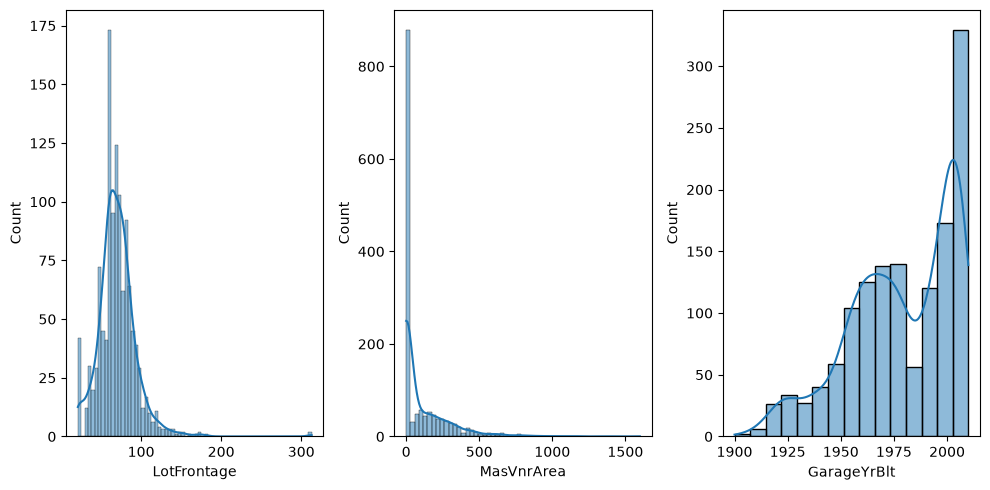

In [405]:
fitur_num_missing = ['LotFrontage', 'MasVnrArea', 'GarageYrBlt']

plt.figure(figsize=(10, 5))

for i, col in enumerate(fitur_num_missing, 1):
    plt.subplot(1, 3, i)
    sns.histplot(
        df[col],
        kde=True
    )

plt.tight_layout()
plt.show()

Karena semuanya tidak berdistribusi normal alias skewed, maka missing value nya diisi dengan median

### Handling Missing Value

In [406]:
for col in fitur_num_missing:
    df[col] = df[col].fillna(df[col].median())

kategorikal_miss_cols = [
    'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'
]

for col in kategorikal_miss_cols:
    df[col] = df[col].fillna('None')

df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

print(df.isnull().sum().sum())

0


### Handling outlier anomali yang sudah di cek menggunakan scatterplot

In [407]:
df = df.drop(df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)].index)

df.shape[0]

1458

Outlier ini harus dihapus barisnya karena sangat tidak masuk akal luasnya segitu besar tapi harganya sangat murah, outlier sisanya tetap dipertahankan karena masih valid namun langka.

Sebagian false-positive dari fitur zero-inflated atau fitur yang memiliki mayoritas nilai 0 , dan skala ordinal/diskrit, sebagian rumah mewah yang memang skewed ke kanan. Menghapus semua outlier nantinya akan membuang banyak informasi penting

### Pisahkan Fitur X dan Y

In [408]:
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

print(X.shape)
print(y.shape)

(1458, 74)
(1458,)


### Encoding menggunakan One Hot Encoding

In [409]:
numeric_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
X = pd.get_dummies(X, drop_first=True)

X.shape

(1458, 242)

One-hot encoding mengubah kategorikal menjadi dummy 0/1. drop_first=True dipakai untuk menghindari dummy trap (multikolinearitas antar dummy). Jumlah kolom bertambah dari 74 → 242.

### Standarisasi menggunakan StandardScaler

In [410]:
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numeric_features] = scaler.fit_transform(X[numeric_features])

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,0.073426,-0.221328,-0.203934,0.658506,-0.517649,1.052959,0.880362,0.523937,0.617283,-0.288867,...,False,False,False,False,True,False,False,False,True,False
1,-0.871868,0.491760,-0.087252,-0.068293,2.177825,0.158428,-0.428115,-0.570739,1.245719,-0.288867,...,False,False,False,False,True,False,False,False,True,False
2,0.073426,-0.078710,0.080162,0.658506,-0.517649,0.986698,0.831900,0.334044,0.108989,-0.288867,...,False,False,False,False,True,False,False,False,True,False
3,0.309749,-0.459024,-0.092325,0.658506,-0.517649,-1.862551,-0.718888,-0.570739,-0.514826,-0.288867,...,False,False,False,False,True,False,False,False,False,False
4,0.073426,0.681917,0.385566,1.385305,-0.517649,0.953567,0.734975,1.384039,0.499451,-0.288867,...,False,False,False,False,True,False,False,False,True,False


Standarisasi dengan StandardScaler hanya diterapkan pada fitur numerik asli hingga mean mendekati 0, std mendekati 1. Kolom dummy hasil encoding dibiarkan 0/1.

## Reduksi Dimensi

### Reduksi kolom multikolinearitas

In [411]:
kolom_multiko = ['GarageArea', 'TotRmsAbvGrd', '1stFlrSF']

X_scaled = X_scaled.drop(columns=kolom_multiko, errors='ignore')
X = X.drop(columns=kolom_multiko, errors='ignore')

Berdasarkan heatmap korelasi: GarageCars-GarageArea 0.88, TotalBsmtSF-1stFlrSF 0.82, TotRmsAbvGrd-GrLivArea 0.83. Dari tiap pasangan yang sangat berkorelasi (>0.8) dibuang satu: GarageArea, 1stFlrSF, TotRmsAbvGrd, disisakan GarageCars, TotalBsmtSF, GrLivArea yang lebih berkorelasi dengan SalePrice.

### Reduksi kolom dengan PCA

In [412]:
pca = PCA(n_components=0.90)

X_pca = pca.fit_transform(X_scaled)

print(X_scaled.shape)
print(X_pca.shape)

print(round(sum(pca.explained_variance_ratio_) * 100, 2))

(1458, 239)
(1458, 45)
90.04


PCA dengan n_components=0.90 mempertahankan 90% varians dan membuang 10% noise. Dimensi turun dari 239 menjadi 132 kolom (90.15% varians terjaga), sehingga model lebih ringan tanpa kehilangan informasi penting.

Text(0.5, 1.0, 'PCA Cumulative Explained Variance')

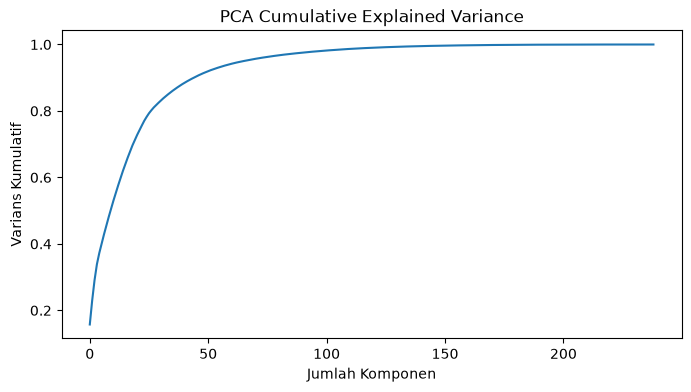

In [413]:
pca_full = PCA()
pca_full.fit(X_scaled)

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel('Jumlah Komponen')
plt.ylabel('Varians Kumulatif')
plt.title('PCA Cumulative Explained Variance')

Kurva menunjukkan varians kumulatif terhadap jumlah komponen. 45 komponen pertama sudah mencakup 90.04% informasi, sisa 194 komponen hanya menambah 10% (noise). Threshold 90% dipilih sebagai tradeoff: dimensi turun drastis 239 → 45 namun informasi penting tetap terjaga.

In [414]:
kolom_pca = [f'PC{i+1}' for i in range(X_pca.shape[1])]

df_pca = pd.DataFrame(X_pca, columns=kolom_pca)
df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC36,PC37,PC38,PC39,PC40,PC41,PC42,PC43,PC44,PC45
0,2.412058,0.107197,-1.396496,-2.196294,0.193748,-0.137381,-1.202088,1.188940,0.385660,-0.937311,...,0.016671,0.273479,0.127745,-0.066316,0.270665,-0.096821,0.275484,0.046564,-0.039346,0.063018
1,-0.149265,-1.381957,1.589491,0.264387,-1.488004,-0.881047,-0.672616,-1.770596,-2.570221,1.216487,...,0.246469,-0.308643,-0.456283,-0.101247,-0.889157,-0.313804,0.515115,0.269180,0.401237,-0.816334
2,2.950341,0.449192,-0.650199,-1.542012,-0.182908,-0.245799,-0.134068,0.055907,0.157833,-1.047847,...,-0.007484,-0.267905,-0.024543,0.141767,0.275225,-0.269107,0.119303,0.507204,-0.020882,-0.229415
3,-0.861611,1.389666,0.856714,-0.088826,0.142592,2.490644,0.691003,1.120413,0.296574,-1.298243,...,-1.421997,0.907316,-0.321861,-0.309439,1.030748,0.108500,-0.495504,-0.260311,0.241512,0.553762
4,4.645453,1.041360,0.765059,-1.233269,0.166723,-0.416004,-0.043758,-0.337635,-0.536261,-1.238596,...,-0.228612,-0.075580,-0.455648,-0.149257,-0.150584,-0.500939,0.146354,0.092100,0.295759,-0.137308


Diubah menjadi dataframe lagi

### Jadikan data.csv

In [415]:
df_final = pd.concat([df_pca, y.reset_index(drop=True)], axis=1)
df_final.to_csv('HousePriceClean.csv', index=False)